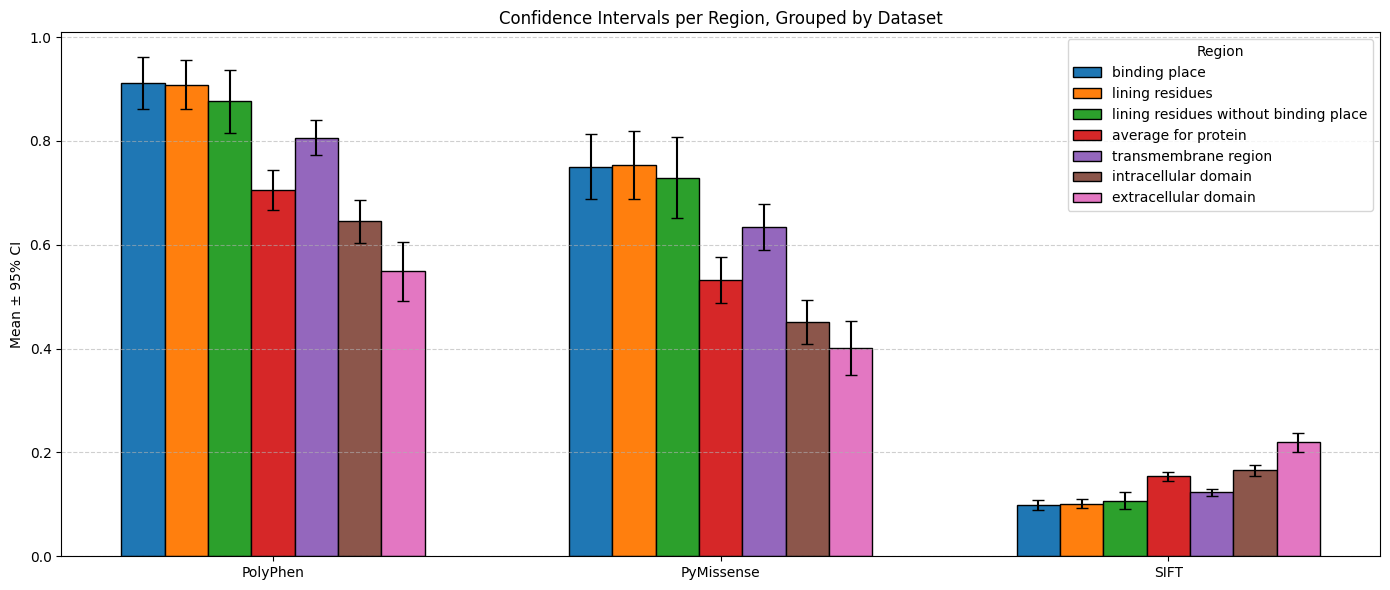

In [245]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt

# load data
def load_and_tag(filepath, dataset_name):
    df = pd.read_csv(filepath, sep="\t")
    df["Dataset"] = dataset_name
    return df

# 3 files
df1 = load_and_tag("C:/Users/annas/Downloads/Štatistika k GLUT, Nina/spojeny_subor_PolyPhen-2.txt", "PolyPhen")
df2 = load_and_tag("C:/Users/annas/Downloads/Štatistika k GLUT, Nina/spojeny_subor_PyMissense.txt", "PyMissense")
df3 = load_and_tag("C:/Users/annas/Downloads/Štatistika k GLUT, Nina/spojeny_subor_SIFT.txt", "SIFT")

# concat datasets
combined = pd.concat([df1, df2, df3], ignore_index=True)
long_df = pd.melt(combined,
                  id_vars=["protein", "Dataset"],
                  var_name="Region",
                  value_name="Value")

# counting CI
def compute_group_stats(df):
    results = []
    for (dataset, region), group in df.groupby(["Dataset", "Region"]):
        mean = group["Value"].mean()
        sem = stats.sem(group["Value"])
        ci = sem * stats.t.ppf((1 + 0.95) / 2., len(group["Value"]) - 1)
        results.append({
            "Dataset": dataset, "Region": region, "Mean": mean, "CI": ci
        })
    return pd.DataFrame(results)

summary_df = compute_group_stats(long_df)

# save correct order
desired_order = [
    "binding place",
    "lining residues",
    "lining residues without binding place",
    "average for protein",
    "transmembrane region",
    "intracellular domain",    
    "extracellular domain"  
]

# check order of regions
summary_df["Region"] = pd.Categorical(summary_df["Region"], categories=desired_order, ordered=True)
summary_df = summary_df.sort_values(["Dataset", "Region"])  #

datasets = summary_df["Dataset"].unique()
regions = desired_order  # order

bar_width = 0.15
gap_between_groups = 0.5  #white space between methods
group_positions = []

# X
start = 0
for _ in datasets:
    positions = [start + i * bar_width for i in range(len(regions))]
    group_positions.append(positions)
    start = positions[-1] + bar_width + gap_between_groups  # white space

# Plot
fig, ax = plt.subplots(figsize=(14, 6))
colors = plt.get_cmap("tab10").colors

for d_idx, dataset in enumerate(datasets):
    for r_idx, region in enumerate(regions):
        row = summary_df[(summary_df["Dataset"] == dataset) & (summary_df["Region"] == region)]
        if not row.empty:
            mean = row["Mean"].values[0]
            ci = row["CI"].values[0]
            x_pos = group_positions[d_idx][r_idx]
            ax.bar(x_pos, mean, width=bar_width, yerr=ci, capsize=4,
                   label=region if d_idx == 0 else "",  # legend
                   color=colors[r_idx % len(colors)], edgecolor="black")

# axes X
xtick_positions = [np.mean(gp) for gp in group_positions]
ax.set_xticks(xtick_positions)
ax.set_xticklabels(datasets)
ax.set_ylabel("Mean ± 95% CI")
ax.set_title("Confidence Intervals per Region, Grouped by Dataset")
ax.legend(title="Region", loc="upper right", frameon=True)
ax.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


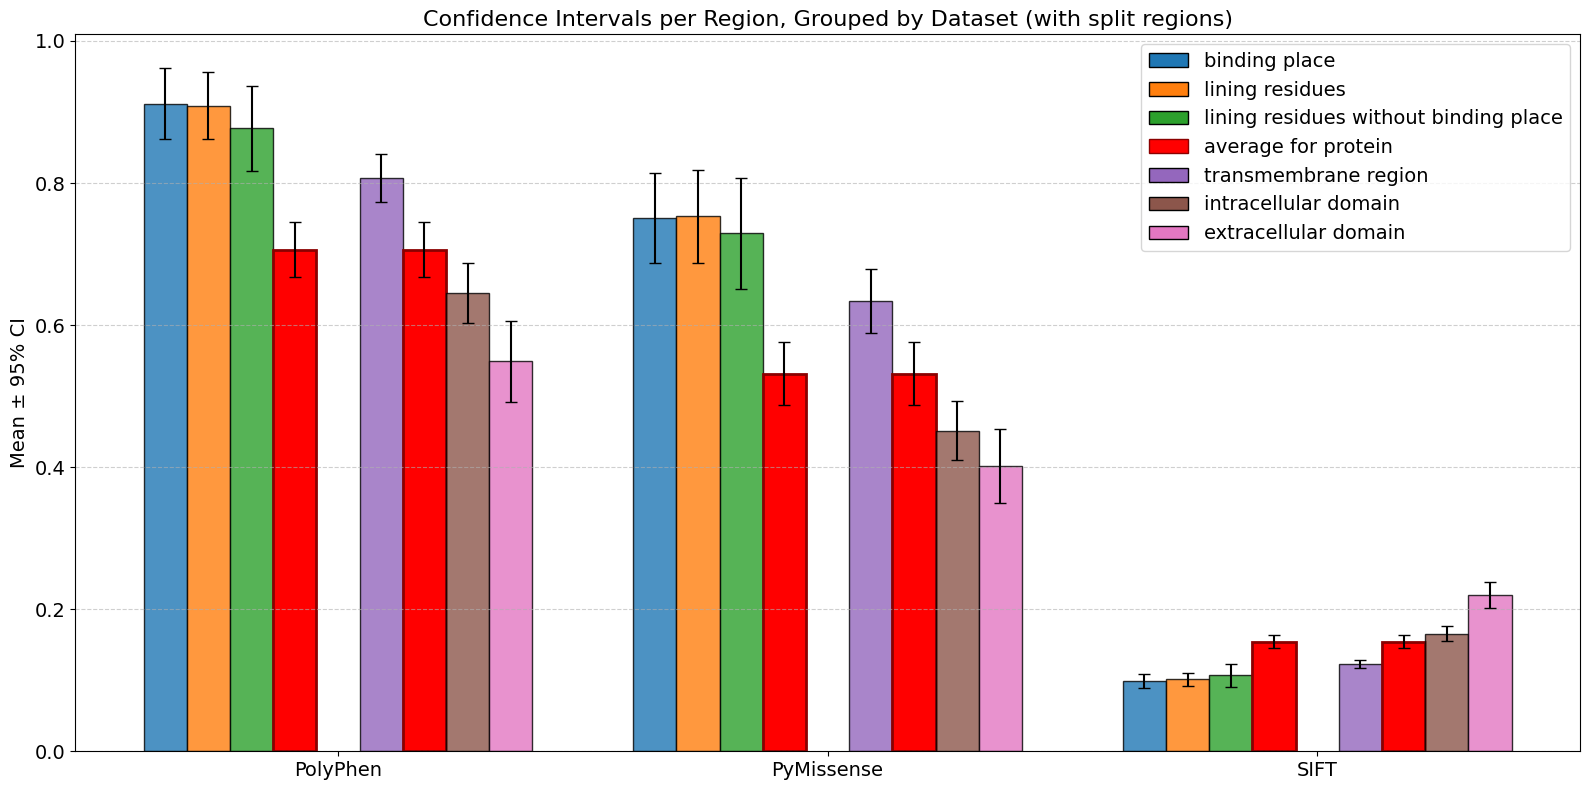

In [246]:


from matplotlib.patches import Patch

group1 = [
    "binding place",
    "lining residues",
    "lining residues without binding place",
    "average for protein"
]

group2 = [
    "transmembrane region",
    "average for protein",
    "intracellular domain",
    "extracellular domain"
]


all_regions_ordered = []
for r in group1 + group2:
    if r not in all_regions_ordered:
        all_regions_ordered.append(r)

# colors
region_color_map = {}
for i, region_name in enumerate(all_regions_ordered):
    if region_name == "average for protein":
        region_color_map[region_name] = ("red", "darkred")
    else:
        base_color = colors[i % len(colors)]
        region_color_map[region_name] = (base_color, "black")
        
        

bar_width = 0.15
gap_between_groups = 0.5  #white space


def calc_positions(start_pos, regions_list):
    return [start_pos + i * bar_width for i in range(len(regions_list))]

# Pro každý dataset spočítáme pozice s mezerou mezi skupinami regionů
group_positions = []
start = 0
for _ in datasets:
    pos_group1 = calc_positions(start, group1)
    start = pos_group1[-1] + (bar_width*2) #+ gap_between_groups  # přidej mezeru mezi skupinami
    pos_group2 = calc_positions(start, group2)
    start = pos_group2[-1] + gap_between_groups   # mezera před další dataset
    
    group_positions.append(pos_group1 + pos_group2)

# Pro legendu sjednotíme regiony (je tam "average for protein" dvakrát, legendu necháme jednou)
regions_combined = group1 + group2[1:]  # Druhé "average for protein" vynecháme v legendě

# Plot
fig, ax = plt.subplots(figsize=(16, 8))
colors = plt.get_cmap("tab10").colors

# figures
for d_idx, dataset in enumerate(datasets):
    for r_idx, x_pos in enumerate(group_positions[d_idx]):
        region_name = (group1 + group2)[r_idx]
        row = summary_df[(summary_df["Dataset"] == dataset) & (summary_df["Region"] == region_name)]
        if not row.empty:
            mean = row["Mean"].values[0]
            ci = row["CI"].values[0]

            bar_color, edge_col = region_color_map[region_name]
            alpha = 1.0 if region_name == "average for protein" else 0.8
            lw = 2 if region_name == "average for protein" else 1

            ax.bar(x_pos, mean, width=bar_width, yerr=ci, capsize=4,
                   label=region_name if d_idx == 0 and r_idx < len(group1) else "",
                   color=bar_color, edgecolor=edge_col, alpha=alpha, linewidth=lw)

# X
xtick_positions = []
for pos in group_positions:
    mid_pos = (pos[0] + pos[-1]) / 2
    xtick_positions.append(mid_pos)

ax.set_xticks(xtick_positions)
ax.set_xticklabels(datasets, fontsize=14)
ax.set_ylabel("Mean ± 95% CI", fontsize=14)
ax.set_title("Confidence Intervals per Region, Grouped by Dataset (with split regions)", fontsize=16)
ax.tick_params(axis='y', labelsize=14)
ax.tick_params(axis='x', labelsize=14)

legend_patches = []
for region_name in all_regions_ordered:
    bar_color, edge_col = region_color_map[region_name]
    patch = Patch(facecolor=bar_color, edgecolor=edge_col, label=region_name)
    legend_patches.append(patch)

ax.legend(handles=legend_patches, loc="upper right", frameon=True, fontsize=14)


ax.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


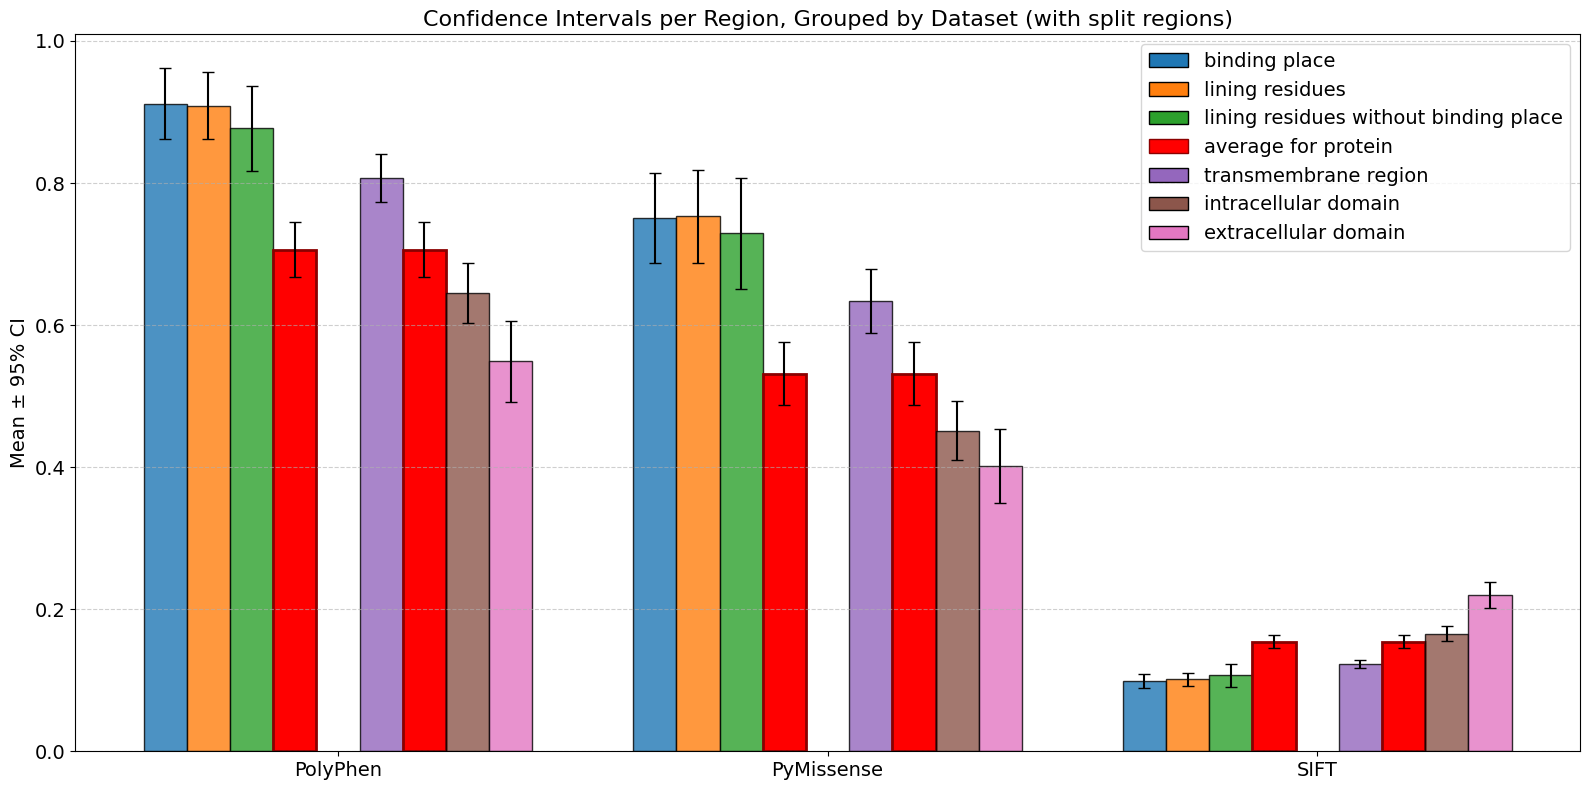

In [247]:
# Rozdělení regionů na 2 skupiny

from matplotlib.patches import Patch

group1 = [
    "binding place",
    "lining residues",
    "lining residues without binding place",
    "average for protein"
]

group2 = [
    "transmembrane region",
    "average for protein",
    "intracellular domain",
    "extracellular domain"
]


all_regions_ordered = []
for r in group1 + group2:
    if r not in all_regions_ordered:
        all_regions_ordered.append(r)

# Přiřazení barev regionům
region_color_map = {}
for i, region_name in enumerate(all_regions_ordered):
    if region_name == "average for protein":
        region_color_map[region_name] = ("red", "darkred")
    else:
        base_color = colors[i % len(colors)]
        region_color_map[region_name] = (base_color, "black")
        
        

bar_width = 0.15
gap_between_groups = 0.5  # mezera mezi skupinami regionů

# Funkce pro výpočet pozic v rámci skupiny
def calc_positions(start_pos, regions_list):
    return [start_pos + i * bar_width for i in range(len(regions_list))]

# Pro každý dataset spočítáme pozice s mezerou mezi skupinami regionů
group_positions = []
start = 0
for _ in datasets:
    pos_group1 = calc_positions(start, group1)
    start = pos_group1[-1] + (bar_width*2) #+ gap_between_groups  # přidej mezeru mezi skupinami
    pos_group2 = calc_positions(start, group2)
    start = pos_group2[-1] + gap_between_groups   # mezera před další dataset
    
    group_positions.append(pos_group1 + pos_group2)

# Pro legendu sjednotíme regiony (je tam "average for protein" dvakrát, legendu necháme jednou)
regions_combined = group1 + group2[1:]  # Druhé "average for protein" vynecháme v legendě

# Plot
fig, ax = plt.subplots(figsize=(16, 8))
colors = plt.get_cmap("tab10").colors

# Při vykreslování:
for d_idx, dataset in enumerate(datasets):
    for r_idx, x_pos in enumerate(group_positions[d_idx]):
        region_name = (group1 + group2)[r_idx]
        row = summary_df[(summary_df["Dataset"] == dataset) & (summary_df["Region"] == region_name)]
        if not row.empty:
            mean = row["Mean"].values[0]
            ci = row["CI"].values[0]

            bar_color, edge_col = region_color_map[region_name]
            alpha = 1.0 if region_name == "average for protein" else 0.8
            lw = 2 if region_name == "average for protein" else 1

            ax.bar(x_pos, mean, width=bar_width, yerr=ci, capsize=4,
                   label=region_name if d_idx == 0 and r_idx < len(group1) else "",
                   color=bar_color, edgecolor=edge_col, alpha=alpha, linewidth=lw)

# Osa X - popisky u datasetů uprostřed skupin
xtick_positions = []
for pos in group_positions:
    mid_pos = (pos[0] + pos[-1]) / 2
    xtick_positions.append(mid_pos)

ax.set_xticks(xtick_positions)
ax.set_xticklabels(datasets, fontsize=14)
ax.set_ylabel("Mean ± 95% CI", fontsize=14)
ax.set_title("Confidence Intervals per Region, Grouped by Dataset (with split regions)", fontsize=16)
ax.tick_params(axis='y', labelsize=14)
ax.tick_params(axis='x', labelsize=14)

legend_patches = []
for region_name in all_regions_ordered:
    bar_color, edge_col = region_color_map[region_name]
    patch = Patch(facecolor=bar_color, edgecolor=edge_col, label=region_name)
    legend_patches.append(patch)

ax.legend(handles=legend_patches, loc="upper right", frameon=True, fontsize=14)

#ax.legend(handles=names, title="Region", loc="upper right", frameon=True)
ax.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


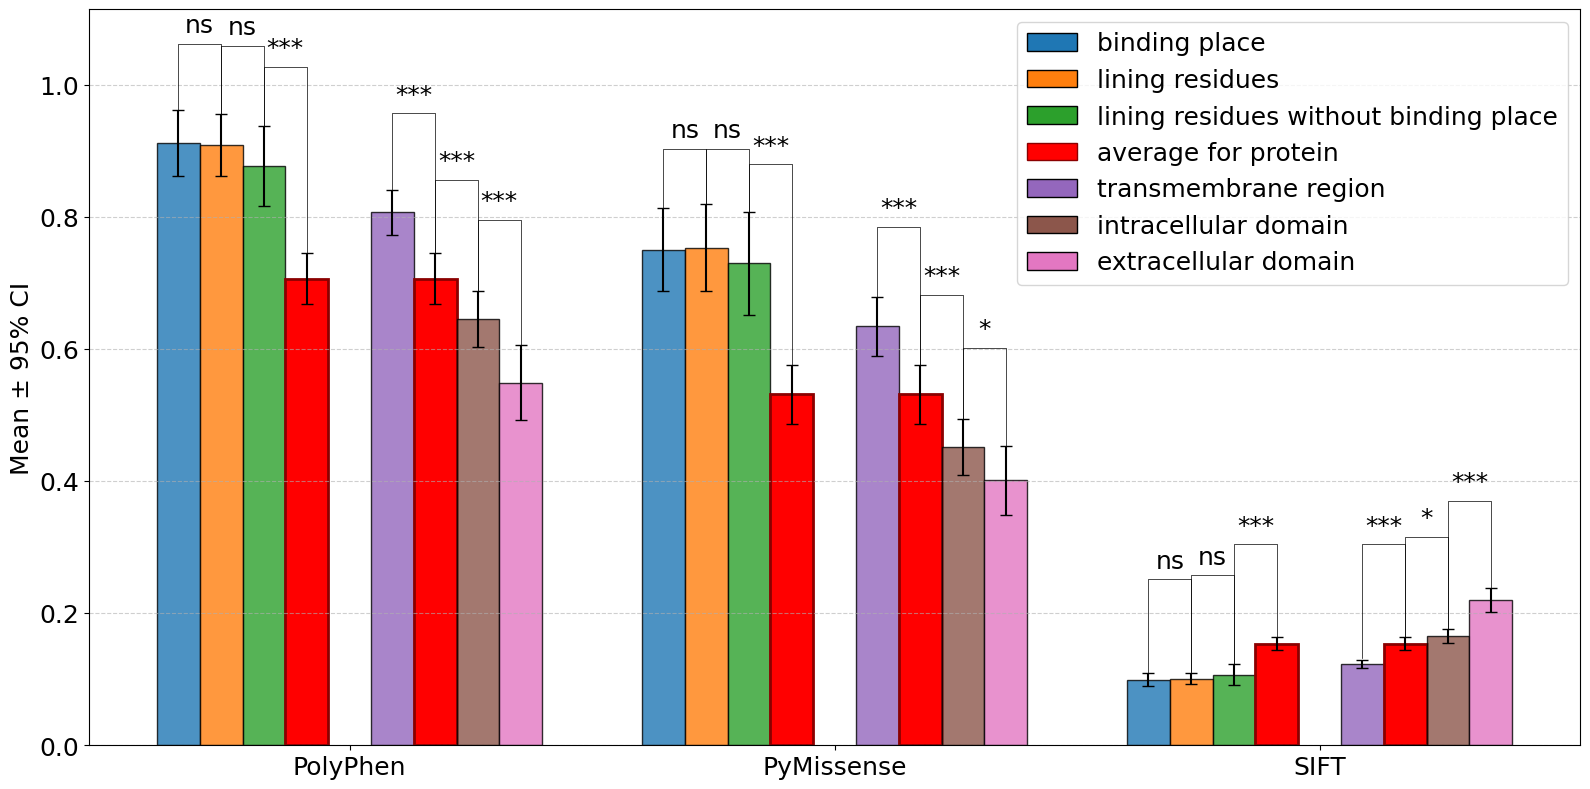

In [248]:
# Rozdělení regionů na 2 skupiny

pval_dict = {
    "PolyPhen": {
        tuple(sorted(["average for protein", "extracellular domain"])): 4.7016e-08,
        tuple(sorted(["average for protein", "intracellular domain"])): 2.0324e-05,
        tuple(sorted(["average for protein", "transmembrane region"])): 9.4888e-09,
        tuple(sorted(["average for protein", "lining residues"])): 8.2314e-08,
        tuple(sorted(["average for protein", "lining residues without binding place"])): 4.7428e-06,
        tuple(sorted(["average for protein", "binding place"])): 1.3799e-07,
        tuple(sorted(["extracellular domain", "intracellular domain"])): 4.6535e-04,
        tuple(sorted(["extracellular domain", "transmembrane region"])): 2.6702e-09,
        tuple(sorted(["extracellular domain", "lining residues"])): 1.4565e-08,
        tuple(sorted(["extracellular domain", "lining residues without binding place"])): 3.0468e-08,
        tuple(sorted(["extracellular domain", "binding place"])): 2.0719e-08,
        tuple(sorted(["intracellular domain", "transmembrane region"])): 1.0922e-08,
        tuple(sorted(["intracellular domain", "lining residues"])): 1.4798e-08,
        tuple(sorted(["intracellular domain", "lining residues without binding place"])): 7.0004e-07,
        tuple(sorted(["intracellular domain", "binding place"])): 2.3943e-08,
        tuple(sorted(["transmembrane region", "lining residues"])): 6.0388e-06,
        tuple(sorted(["transmembrane region", "lining residues without binding place"])): 3.8088e-03,
        tuple(sorted(["transmembrane region", "binding place"])): 6.1451e-06,
        tuple(sorted(["lining residues", "lining residues without binding place"])): 1.1004e-01,
        tuple(sorted(["lining residues", "binding place"])): 7.0774e-01,
        tuple(sorted(["lining residues without binding place", "binding place"])): 1.1682e-01,
    },
    "PyMissense": {
        tuple(sorted(["average for protein", "extracellular domain"])): 7.2597e-08,
        tuple(sorted(["average for protein", "intracellular domain"])): 9.5310e-07,
        tuple(sorted(["average for protein", "transmembrane region"])): 1.0342e-10,
        tuple(sorted(["average for protein", "lining residues"])): 1.8403e-08,
        tuple(sorted(["average for protein", "lining residues without binding place"])): 1.1127e-06,
        tuple(sorted(["average for protein", "binding place"])): 3.8661e-08,
        tuple(sorted(["extracellular domain", "intracellular domain"])): 1.7733e-02,
        tuple(sorted(["extracellular domain", "transmembrane region"])): 8.4318e-10,
        tuple(sorted(["extracellular domain", "lining residues"])): 9.4237e-09,
        tuple(sorted(["extracellular domain", "lining residues without binding place"])): 1.0935e-07,
        tuple(sorted(["extracellular domain", "binding place"])): 9.4792e-09,
        tuple(sorted(["intracellular domain", "transmembrane region"])): 5.0430e-10,
        tuple(sorted(["intracellular domain", "lining residues"])): 2.0400e-09,
        tuple(sorted(["intracellular domain", "lining residues without binding place"])): 4.9788e-08,
        tuple(sorted(["intracellular domain", "binding place"])): 4.1114e-09,
        tuple(sorted(["transmembrane region", "lining residues"])): 1.5306e-06,
        tuple(sorted(["transmembrane region", "lining residues without binding place"])): 3.3191e-04,
        tuple(sorted(["transmembrane region", "binding place"])): 5.7395e-06,
        tuple(sorted(["lining residues", "lining residues without binding place"])): 5.8257e-02,
        tuple(sorted(["lining residues", "binding place"])): 7.6761e-01,
        tuple(sorted(["lining residues without binding place", "binding place"])): 3.1718e-01,
    },
    "SIFT": {
        tuple(sorted(["average for protein", "extracellular domain"])): 1.1443e-08,
        tuple(sorted(["average for protein", "intracellular domain"])): 2.5205e-02,
        tuple(sorted(["average for protein", "transmembrane region"])): 2.1147e-08,
        tuple(sorted(["average for protein", "lining residues"])): 1.2496e-06,
        tuple(sorted(["average for protein", "lining residues without binding place"])): 3.8475e-04,
        tuple(sorted(["average for protein", "binding place"])): 2.3144e-08,
        tuple(sorted(["extracellular domain", "intracellular domain"])): 4.3728e-05,
        tuple(sorted(["extracellular domain", "transmembrane region"])): 1.9335e-09,
        tuple(sorted(["extracellular domain", "lining residues"])): 1.9853e-08,
        tuple(sorted(["extracellular domain", "lining residues without binding place"])): 1.1860e-06,
        tuple(sorted(["extracellular domain", "binding place"])): 6.9751e-10,
        tuple(sorted(["intracellular domain", "transmembrane region"])): 2.7442e-06,
        tuple(sorted(["intracellular domain", "lining residues"])): 5.0758e-07,
        tuple(sorted(["intracellular domain", "lining residues without binding place"])): 1.3136e-05,
        tuple(sorted(["intracellular domain", "binding place"])): 5.7968e-07,
        tuple(sorted(["transmembrane region", "lining residues"])): 2.9030e-04,
        tuple(sorted(["transmembrane region", "lining residues without binding place"])): 1.0467e-01,
        tuple(sorted(["transmembrane region", "binding place"])): 4.7936e-07,
        tuple(sorted(["lining residues", "lining residues without binding place"])): 3.6229e-01,
        tuple(sorted(["lining residues", "binding place"])): 6.4907e-01,
        tuple(sorted(["lining residues without binding place", "binding place"])): 4.1750e-01,
    }
}




def draw_bracket_with_pvalue(ax, x1, x2, y1 , y2 , y, text, height=0.05, color='black', lw=1.5, text_offset=0.01):
    """
    Nakreslí svorku mezi x1 a x2 ve výšce y a nad ni p-value text.
    """
    ax.plot([x1, x1, x2, x2], [y1 + 0.01, y + 0.05, y + 0.05, y2 + 0.01], color=color, lw=0.5)
    ax.text((x1 + x2) / 2, y + height + text_offset, text, ha='center', va='bottom', fontsize=18, color=color)


from matplotlib.patches import Patch

group1 = [
    "binding place",
    "lining residues",
    "lining residues without binding place",
    "average for protein"
]

group2 = [
    "transmembrane region",
    "average for protein",
    "intracellular domain",
    "extracellular domain"
]


all_regions_ordered = []
for r in group1 + group2:
    if r not in all_regions_ordered:
        all_regions_ordered.append(r)
        


# Přiřazení barev regionům
region_color_map = {}
for i, region_name in enumerate(all_regions_ordered):
    if region_name == "average for protein":
        region_color_map[region_name] = ("red", "darkred")
    else:
        base_color = colors[i % len(colors)]
        region_color_map[region_name] = (base_color, "black")
        
        

bar_width = 0.15
gap_between_groups = 0.5  # mezera mezi skupinami regionů

# Funkce pro výpočet pozic v rámci skupiny
def calc_positions(start_pos, regions_list):
    return [start_pos + i * bar_width for i in range(len(regions_list))]

# Pro každý dataset spočítáme pozice s mezerou mezi skupinami regionů
group_positions = []
start = 0
for _ in datasets:
    pos_group1 = calc_positions(start, group1)
    start = pos_group1[-1] + (bar_width*2) #+ gap_between_groups  # přidej mezeru mezi skupinami
    pos_group2 = calc_positions(start, group2)
    start = pos_group2[-1] + gap_between_groups   # mezera před další dataset
    
    group_positions.append(pos_group1 + pos_group2)

# Pro legendu sjednotíme regiony (je tam "average for protein" dvakrát, legendu necháme jednou)
regions_combined = group1 + group2[1:]  # Druhé "average for protein" vynecháme v legendě

# Plot
fig, ax = plt.subplots(figsize=(16, 8))
colors = plt.get_cmap("tab10").colors




# Při vykreslování:
for d_idx, dataset in enumerate(datasets):
    for r_idx, x_pos in enumerate(group_positions[d_idx]):
        region_name = (group1 + group2)[r_idx]
        row = summary_df[(summary_df["Dataset"] == dataset) & (summary_df["Region"] == region_name)]
        if not row.empty:
            mean = row["Mean"].values[0]
            ci = row["CI"].values[0]

            bar_color, edge_col = region_color_map[region_name]
            alpha = 1.0 if region_name == "average for protein" else 0.8
            lw = 2 if region_name == "average for protein" else 1

            ax.bar(x_pos, mean, width=bar_width, yerr=ci, capsize=4,
                   label=region_name if d_idx == 0 and r_idx < len(group1) else "",
                   color=bar_color, edgecolor=edge_col, alpha=alpha, linewidth=lw)
    
    for i in range(len(group_positions[d_idx]) - 1):
        x1 = group_positions[d_idx][i]
        x2 = group_positions[d_idx][i + 1]

        region1 = (group1 + group2)[i]
        region2 = (group1 + group2)[i + 1]
        
        # přeskoč přechod mezi skupinami
        if region1 == group1[-1] and region2 == group2[0]:
            continue

        row1 = summary_df[(summary_df["Dataset"] == dataset) & (summary_df["Region"] == region1)]
        row2 = summary_df[(summary_df["Dataset"] == dataset) & (summary_df["Region"] == region2)]

        if not row1.empty and not row2.empty:
            y1 = row1["Mean"].values[0]
            y2 = row2["Mean"].values[0]
            y = max(y1, y2) + 0.1

            # p-hodnota, pokud existuje
            p_val = pval_dict.get(dataset, {}).get((region1, region2)) or \
                    pval_dict.get(dataset, {}).get((region2, region1))

            if p_val is not None:
                # volitelně můžeš formátovat:
                if p_val < 0.0005:
                    p_value_text = f"***"
                elif p_val > 0.0005 and p_val < 0.005:
                    p_value_text = f"**"
                elif p_val < 0.05:
                    p_value_text = f"*"
                else:
                    p_value_text = f"ns"
            else:
                p_value_text = ""

            draw_bracket_with_pvalue(ax, x1, x2, y1, y2, y, p_value_text)
# Osa X - popisky u datasetů uprostřed skupin
xtick_positions = []
for pos in group_positions:
    mid_pos = (pos[0] + pos[-1]) / 2
    xtick_positions.append(mid_pos)

ax.set_xticks(xtick_positions)
ax.set_xticklabels(datasets, fontsize=18)
ax.set_ylabel("Mean ± 95% CI", fontsize=18)

ax.tick_params(axis='y', labelsize=18)
ax.tick_params(axis='x', labelsize=18)

legend_patches = []
for region_name in all_regions_ordered:
    bar_color, edge_col = region_color_map[region_name]
    patch = Patch(facecolor=bar_color, edgecolor=edge_col, label=region_name)
    legend_patches.append(patch)

ax.legend(handles=legend_patches, loc="upper right", frameon=True, fontsize=18)


ax.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


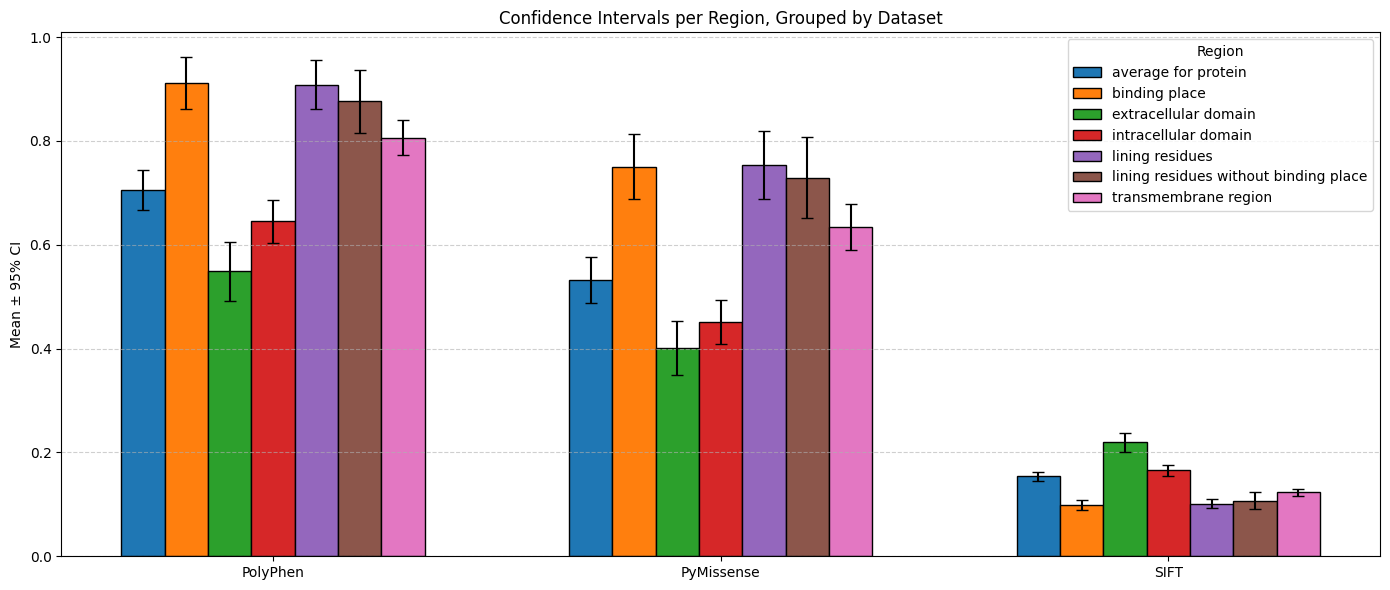

In [250]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt

# load
def load_and_tag(filepath, dataset_name):
    df = pd.read_csv(filepath, sep="\t")
    df["Dataset"] = dataset_name
    return df
#3 files
df1 = load_and_tag("C:/Users/annas/Downloads/Štatistika k GLUT, Nina/spojeny_subor_PolyPhen-2.txt", "PolyPhen")
df2 = load_and_tag("C:/Users/annas/Downloads/Štatistika k GLUT, Nina/spojeny_subor_PyMissense.txt", "PyMissense")
df3 = load_and_tag("C:/Users/annas/Downloads/Štatistika k GLUT, Nina/spojeny_subor_SIFT.txt", "SIFT")


combined = pd.concat([df1, df2, df3], ignore_index=True)
long_df = pd.melt(combined,
                  id_vars=["protein", "Dataset"],
                  var_name="Region",
                  value_name="Value")

# ---- 2. Výpočet CI ----
def compute_group_stats(df):
    results = []
    for (dataset, region), group in df.groupby(["Dataset", "Region"]):
        mean = group["Value"].mean()
        sem = stats.sem(group["Value"])
        ci = sem * stats.t.ppf((1 + 0.95) / 2., len(group["Value"]) - 1)
        results.append({
            "Dataset": dataset, "Region": region, "Mean": mean, "CI": ci
        })
    return pd.DataFrame(results)




summary_df = compute_group_stats(long_df)




# figure
datasets = summary_df["Dataset"].unique()
regions = summary_df["Region"].unique()

bar_width = 0.15
gap_between_groups = 0.5  # mezera mezi dataset skupinami
group_positions = []

# Vypočti X pozice: každá skupina bude mít n regionů blízko sebe
start = 0
for _ in datasets:
    positions = [start + i * bar_width for i in range(len(regions))]
    group_positions.append(positions)
    start = positions[-1] + bar_width + gap_between_groups  # přidej mezeru

# Plot
fig, ax = plt.subplots(figsize=(14, 6))
colors = plt.get_cmap("tab10").colors

for d_idx, dataset in enumerate(datasets):
    for r_idx, region in enumerate(regions):
        row = summary_df[(summary_df["Dataset"] == dataset) & (summary_df["Region"] == region)]
        mean = row["Mean"].values[0]
        ci = row["CI"].values[0]
        x_pos = group_positions[d_idx][r_idx]
        ax.bar(x_pos, mean, width=bar_width, yerr=ci, capsize=4,
               label=region if d_idx == 0 else "",  # legendu jen 1x
               color=colors[r_idx % len(colors)], edgecolor="black")

# X
xtick_positions = [np.mean(gp) for gp in group_positions]
ax.set_xticks(xtick_positions)
ax.set_xticklabels(datasets)
ax.set_ylabel("Mean ± 95% CI")
ax.set_title("Confidence Intervals per Region, Grouped by Dataset")

ax.legend(title="Region", loc="upper right", frameon=True)
ax.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


In [251]:
from scipy.stats import ttest_rel
from itertools import combinations



columns_to_compare = [
    "average for protein",
    "extracellular domain", 
    "intracellular domain",
    "transmembrane region", 
    "lining residues",
    "lining residues without binding place",
    "binding place", 
   
]

# --- Funkce na výpočet p-hodnot mezi všemi dvojicemi sloupců ---
def compute_pvalues(df, dataset_name):
    print(f"\n📊 P-values for {dataset_name}:")
    for col1, col2 in combinations(columns_to_compare, 2):
        values1 = df[col1]
        values2 = df[col2]
    
        stat, p = ttest_rel(values1, values2)
        print(f"{col1} vs {col2}: p = {p:.4e}")

#
compute_pvalues(df1, "PolyPhen")
compute_pvalues(df2, "PyMissense")
compute_pvalues(df3, "SIFT")


📊 P-values for PolyPhen:
average for protein vs extracellular domain: p = 4.7016e-08
average for protein vs intracellular domain: p = 2.0324e-05
average for protein vs transmembrane region: p = 9.4888e-09
average for protein vs lining residues: p = 8.2314e-08
average for protein vs lining residues without binding place: p = 4.7428e-06
average for protein vs binding place: p = 1.3799e-07
extracellular domain vs intracellular domain: p = 4.6535e-04
extracellular domain vs transmembrane region: p = 2.6702e-09
extracellular domain vs lining residues: p = 1.4565e-08
extracellular domain vs lining residues without binding place: p = 3.0468e-08
extracellular domain vs binding place: p = 2.0719e-08
intracellular domain vs transmembrane region: p = 1.0922e-08
intracellular domain vs lining residues: p = 1.4798e-08
intracellular domain vs lining residues without binding place: p = 7.0004e-07
intracellular domain vs binding place: p = 2.3943e-08
transmembrane region vs lining residues: p = 6.038

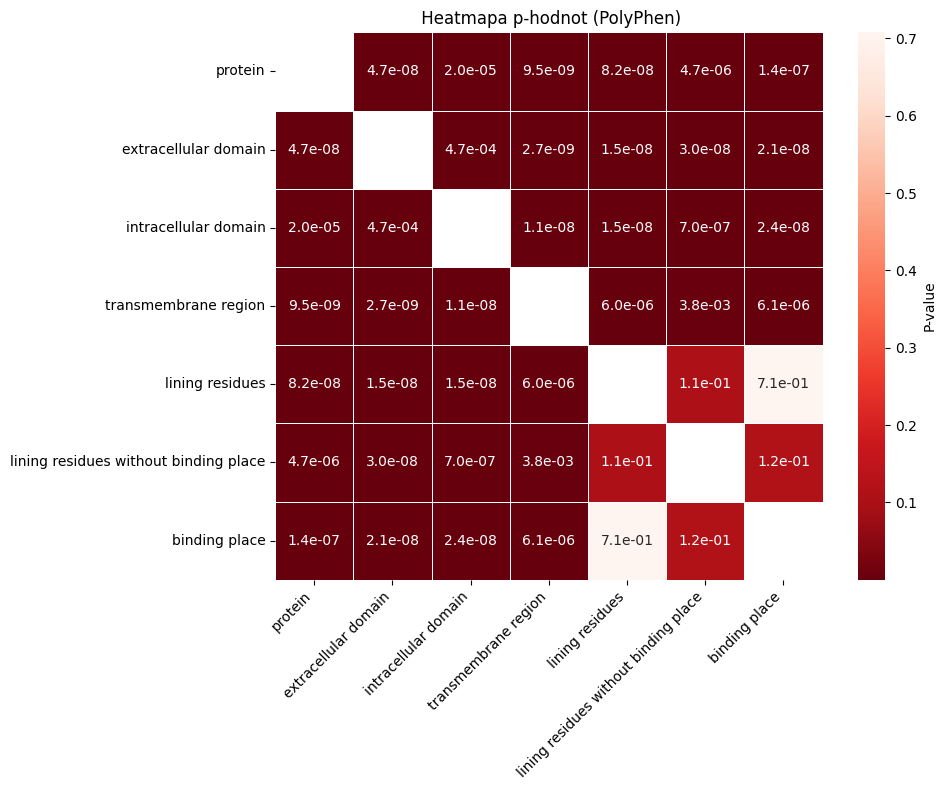

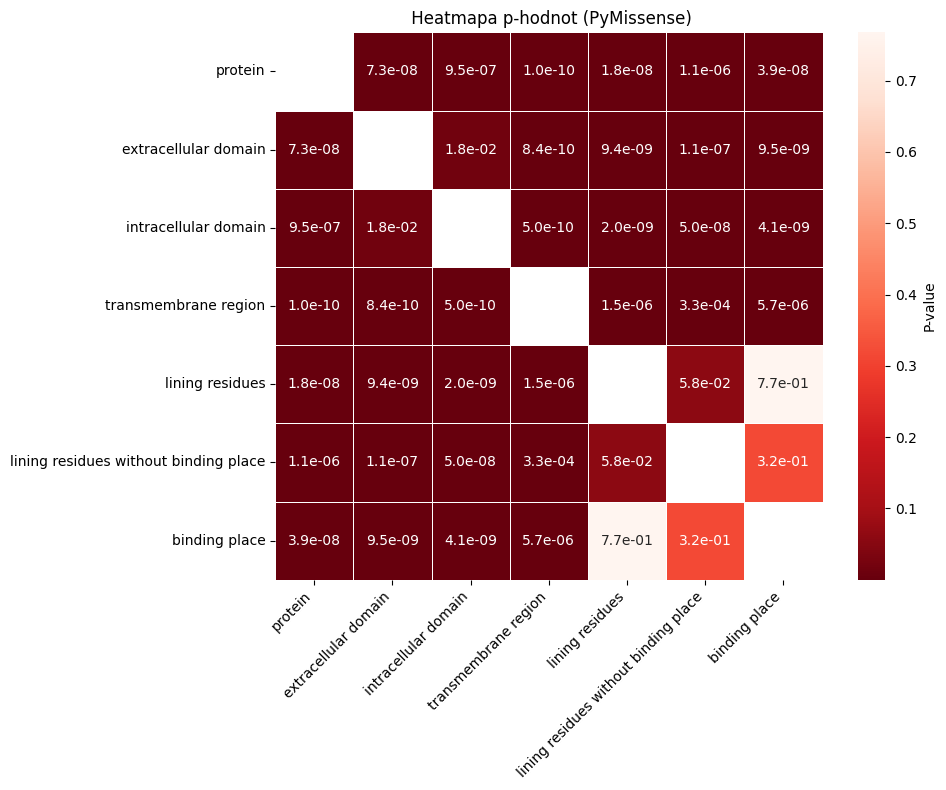

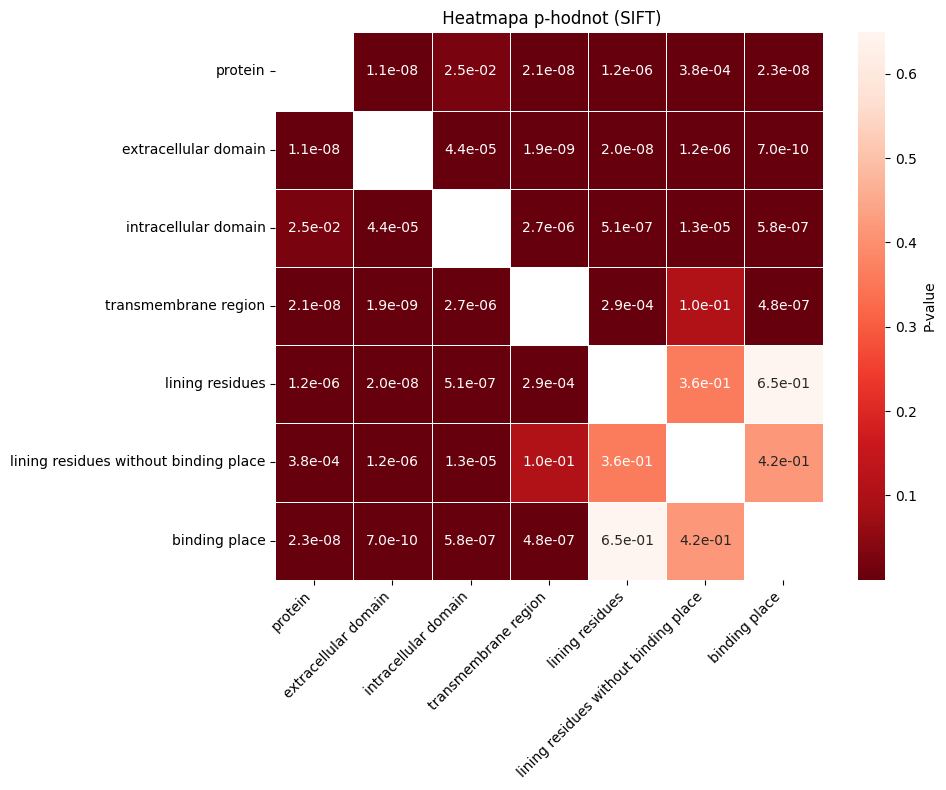

In [252]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

domains = [
    "protein",
    "extracellular domain",
    "intracellular domain",
    "transmembrane region",
    "lining residues",
    "lining residues without binding place",
    "binding place"
]

def create_heatmap(data, title):
    heatmap_df = pd.DataFrame(index=domains, columns=domains, dtype=float)
    for d1, d2, p in data:
        heatmap_df.loc[d1, d2] = p
        heatmap_df.loc[d2, d1] = p
    np.fill_diagonal(heatmap_df.values, np.nan)

    plt.figure(figsize=(10, 8))
    sns.heatmap(
        heatmap_df,
        cmap="Reds_r",
        annot=True,
        fmt=".1e",
        linewidths=0.5,
        cbar_kws={'label': 'P-value'},
        square=True,
        mask=heatmap_df.isnull()
    )
    plt.title(title)
    plt.xticks(rotation=45, ha="right")
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()


polyphen_data = [
    ("protein", "extracellular domain", 4.7016e-08),
    ("protein", "intracellular domain", 2.0324e-05),
    ("protein", "transmembrane region", 9.4888e-09),
    ("protein", "lining residues", 8.2314e-08),
    ("protein", "lining residues without binding place", 4.7428e-06),
    ("protein", "binding place", 1.3799e-07),
    ("extracellular domain", "intracellular domain", 4.6535e-04),
    ("extracellular domain", "transmembrane region", 2.6702e-09),
    ("extracellular domain", "lining residues", 1.4565e-08),
    ("extracellular domain", "lining residues without binding place", 3.0468e-08),
    ("extracellular domain", "binding place", 2.0719e-08),
    ("intracellular domain", "transmembrane region", 1.0922e-08),
    ("intracellular domain", "lining residues", 1.4798e-08),
    ("intracellular domain", "lining residues without binding place", 7.0004e-07),
    ("intracellular domain", "binding place", 2.3943e-08),
    ("transmembrane region", "lining residues", 6.0388e-06),
    ("transmembrane region", "lining residues without binding place", 3.8088e-03),
    ("transmembrane region", "binding place", 6.1451e-06),
    ("lining residues", "lining residues without binding place", 1.1004e-01),
    ("lining residues", "binding place", 7.0774e-01),
    ("lining residues without binding place", "binding place", 1.1682e-01)
]

pymissense_data = [
    ("protein", "extracellular domain", 7.2597e-08),
    ("protein", "intracellular domain", 9.5310e-07),
    ("protein", "transmembrane region", 1.0342e-10),
    ("protein", "lining residues", 1.8403e-08),
    ("protein", "lining residues without binding place", 1.1127e-06),
    ("protein", "binding place", 3.8661e-08),
    ("extracellular domain", "intracellular domain", 1.7733e-02),
    ("extracellular domain", "transmembrane region", 8.4318e-10),
    ("extracellular domain", "lining residues", 9.4237e-09),
    ("extracellular domain", "lining residues without binding place", 1.0935e-07),
    ("extracellular domain", "binding place", 9.4792e-09),
    ("intracellular domain", "transmembrane region", 5.0430e-10),
    ("intracellular domain", "lining residues", 2.0400e-09),
    ("intracellular domain", "lining residues without binding place", 4.9788e-08),
    ("intracellular domain", "binding place", 4.1114e-09),
    ("transmembrane region", "lining residues", 1.5306e-06),
    ("transmembrane region", "lining residues without binding place", 3.3191e-04),
    ("transmembrane region", "binding place", 5.7395e-06),
    ("lining residues", "lining residues without binding place", 5.8257e-02),
    ("lining residues", "binding place", 7.6761e-01),
    ("lining residues without binding place", "binding place", 3.1718e-01)
]

sift_data = [
    ("protein", "extracellular domain", 1.1443e-08),
    ("protein", "intracellular domain", 2.5205e-02),
    ("protein", "transmembrane region", 2.1147e-08),
    ("protein", "lining residues", 1.2496e-06),
    ("protein", "lining residues without binding place", 3.8475e-04),
    ("protein", "binding place", 2.3144e-08),
    ("extracellular domain", "intracellular domain", 4.3728e-05),
    ("extracellular domain", "transmembrane region", 1.9335e-09),
    ("extracellular domain", "lining residues", 1.9853e-08),
    ("extracellular domain", "lining residues without binding place", 1.1860e-06),
    ("extracellular domain", "binding place", 6.9751e-10),
    ("intracellular domain", "transmembrane region", 2.7442e-06),
    ("intracellular domain", "lining residues", 5.0758e-07),
    ("intracellular domain", "lining residues without binding place", 1.3136e-05),
    ("intracellular domain", "binding place", 5.7968e-07),
    ("transmembrane region", "lining residues", 2.9030e-04),
    ("transmembrane region", "lining residues without binding place", 1.0467e-01),
    ("transmembrane region", "binding place", 4.7936e-07),
    ("lining residues", "lining residues without binding place", 3.6229e-01),
    ("lining residues", "binding place", 6.4907e-01),
    ("lining residues without binding place", "binding place", 4.1750e-01)
]

# show
create_heatmap(polyphen_data, " Heatmapa p-hodnot (PolyPhen)")
create_heatmap(pymissense_data, " Heatmapa p-hodnot (PyMissense)")
create_heatmap(sift_data, " Heatmapa p-hodnot (SIFT)")


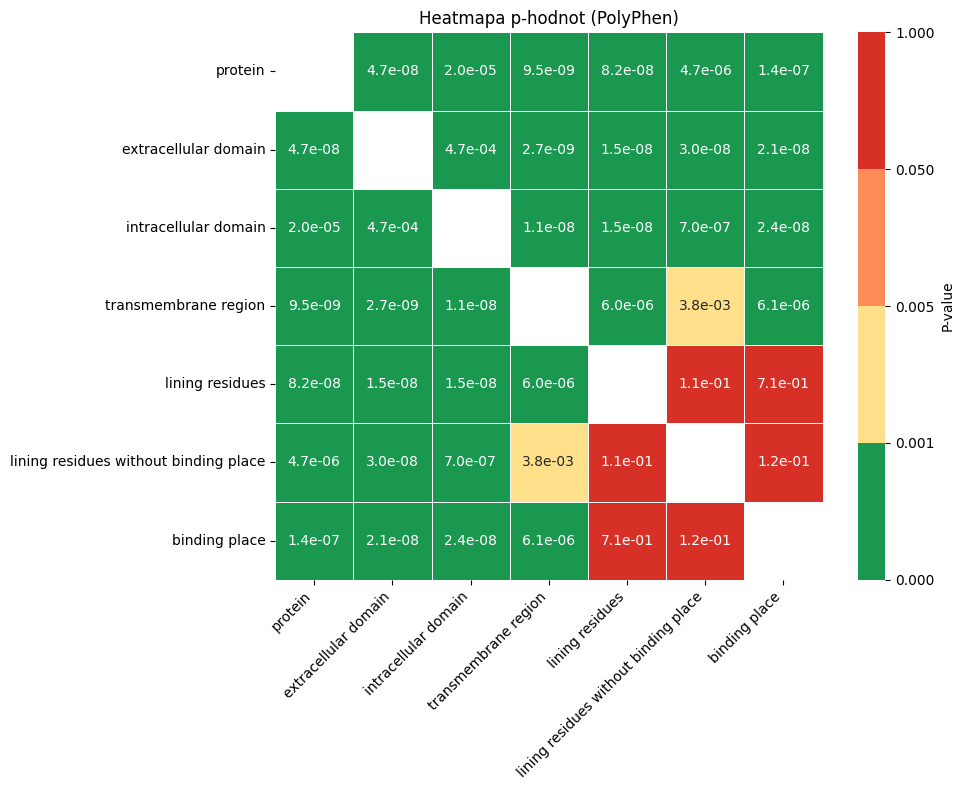

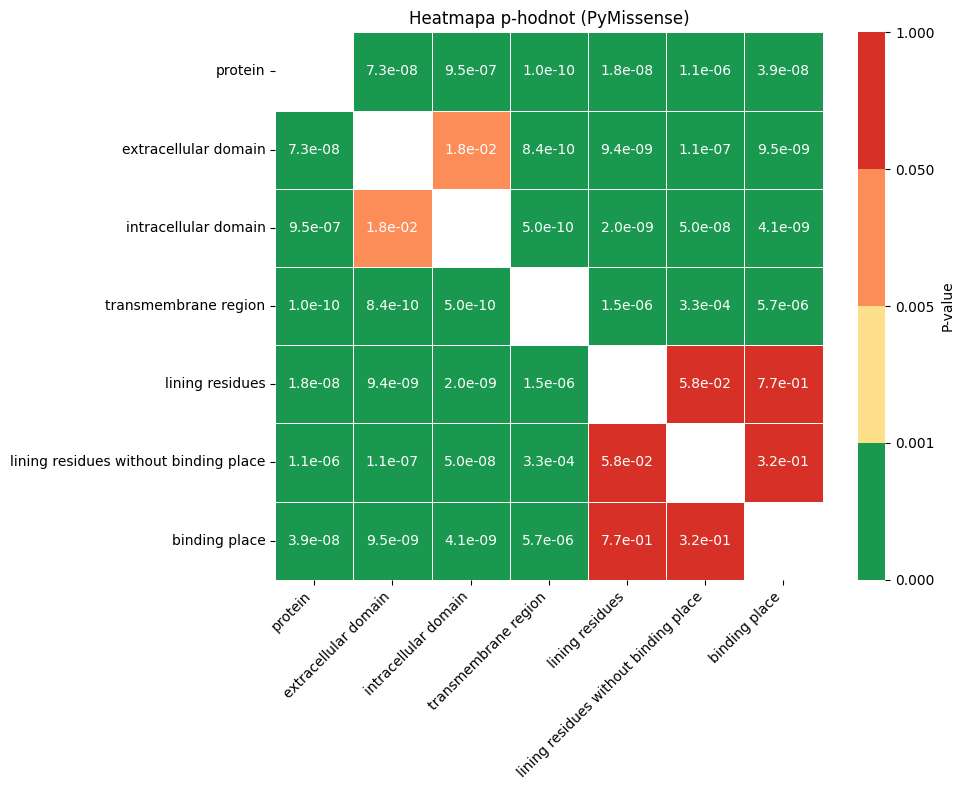

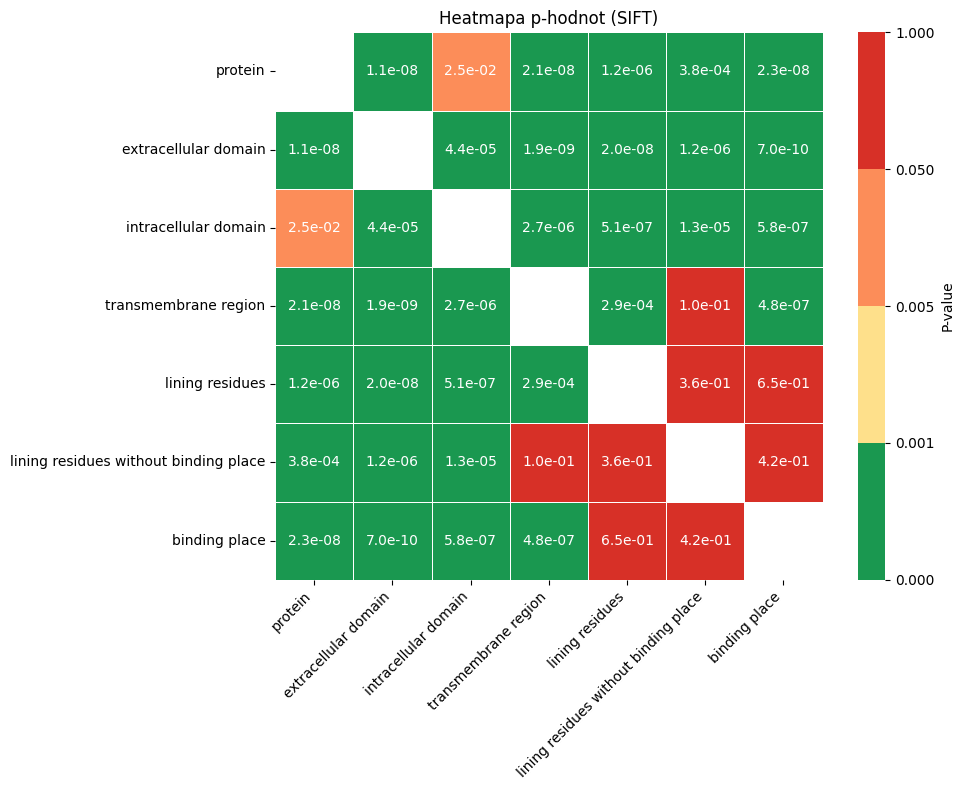

In [253]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

domains = [
    "protein",
    "extracellular domain",
    "intracellular domain",
    "transmembrane region",
    "lining residues",
    "lining residues without binding place",
    "binding place"
]

def create_heatmap(data, title):
    #headmap
    heatmap_df = pd.DataFrame(index=domains, columns=domains, dtype=float)
    for d1, d2, p in data:
        heatmap_df.loc[d1, d2] = p
        heatmap_df.loc[d2, d1] = p
    np.fill_diagonal(heatmap_df.values, np.nan)

    # Vcolormap
    bounds = [0, 0.0005, 0.005, 0.05, 1]
    colors = ["#1a9850", "#fee08b", "#fc8d59", "#d73027"]  # green, yellow, orange, red
    cmap = mcolors.ListedColormap(colors)
    norm = mcolors.BoundaryNorm(bounds, cmap.N)

    # heatmap
    plt.figure(figsize=(10, 8))
    sns.heatmap(
        heatmap_df,
        cmap=cmap,
        norm=norm,
        annot=True,
        fmt=".1e",
        linewidths=0.5,
        cbar_kws={'label': 'P-value'},
        square=True,
        mask=heatmap_df.isnull()
    )
    plt.title(title)
    plt.xticks(rotation=45, ha="right")
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()
    
create_heatmap(polyphen_data, "Heatmapa p-hodnot (PolyPhen)")
create_heatmap(pymissense_data, "Heatmapa p-hodnot (PyMissense)")
create_heatmap(sift_data, "Heatmapa p-hodnot (SIFT)")


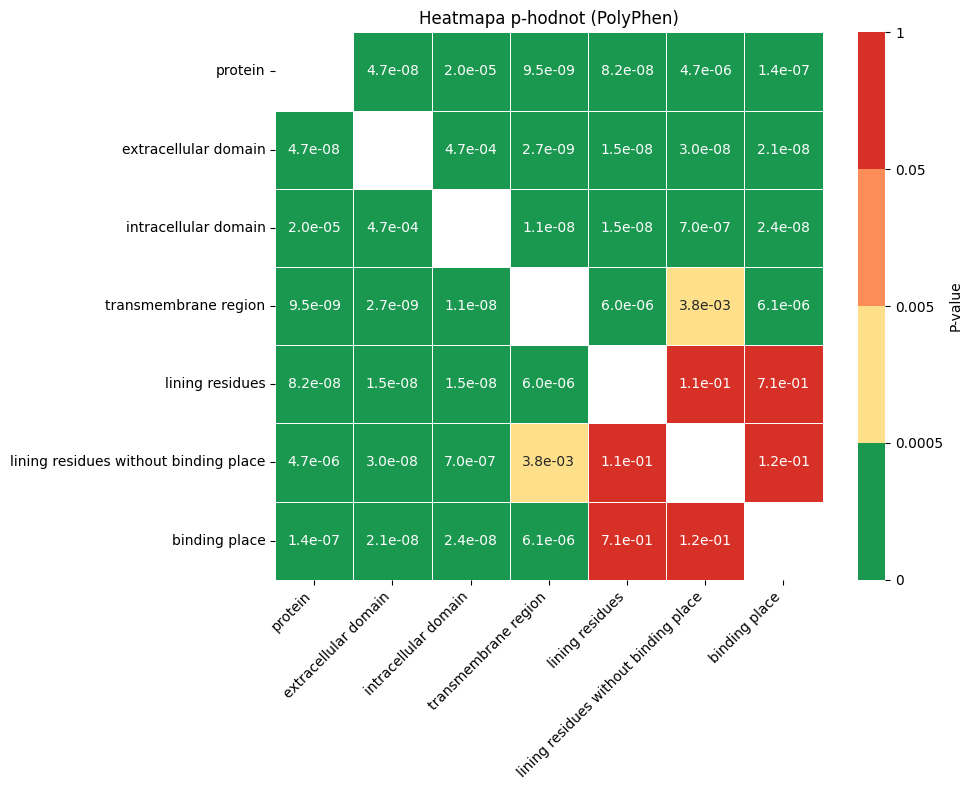

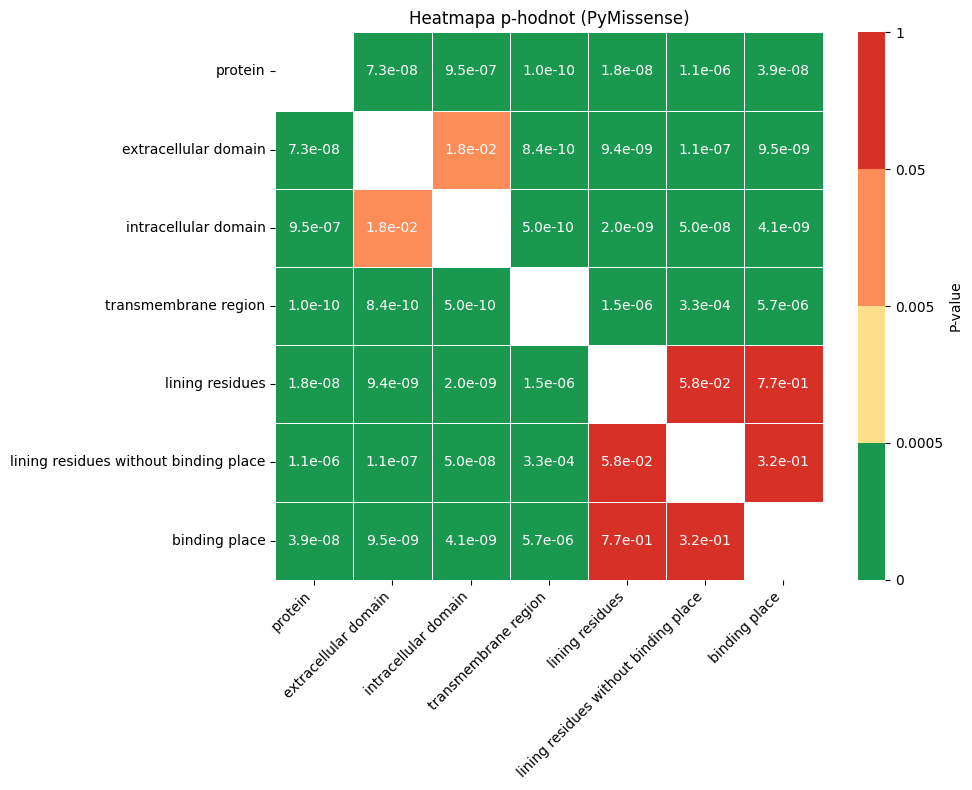

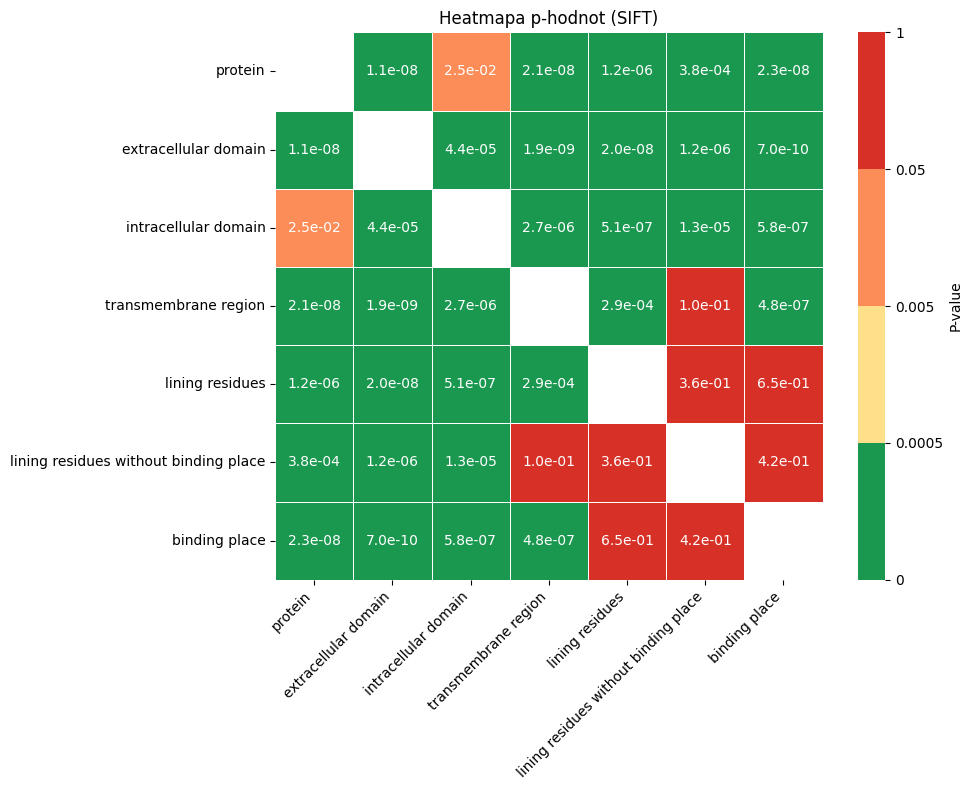

In [254]:
def create_heatmap(data, title):
    heatmap_df = pd.DataFrame(index=domains, columns=domains, dtype=float)
    for d1, d2, p in data:
        heatmap_df.loc[d1, d2] = p
        heatmap_df.loc[d2, d1] = p
    np.fill_diagonal(heatmap_df.values, np.nan)

    # colormap
    bounds = [0, 0.0005, 0.005, 0.05, 1]
    colors = ["#1a9850", "#fee08b", "#fc8d59", "#d73027"]
    cmap = mcolors.ListedColormap(colors)
    norm = mcolors.BoundaryNorm(bounds, cmap.N)

    # heatmap
    plt.figure(figsize=(10, 8))
    ax = sns.heatmap(
        heatmap_df,
        cmap=cmap,
        norm=norm,
        annot=True,
        fmt=".1e",
        linewidths=0.5,
        cbar_kws={'label': 'P-value'},
        square=True,
        mask=heatmap_df.isnull()
    )

    
    colorbar = ax.collections[0].colorbar
    colorbar.set_ticks(bounds)
    colorbar.set_ticklabels(["0", "0.0005", "0.005", "0.05", "1"])

    plt.title(title)
    plt.xticks(rotation=45, ha="right")
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()
    
create_heatmap(polyphen_data, "Heatmapa p-hodnot (PolyPhen)")
create_heatmap(pymissense_data, "Heatmapa p-hodnot (PyMissense)")
create_heatmap(sift_data, "Heatmapa p-hodnot (SIFT)")


In [255]:
import matplotlib.colors as mcolors

def create_heatmap(data, title):
    heatmap_df = pd.DataFrame(index=domains, columns=domains, dtype=float)
    for d1, d2, p in data:
        heatmap_df.loc[d1, d2] = p
        heatmap_df.loc[d2, d1] = p
    np.fill_diagonal(heatmap_df.values, np.nan)

    # --- Vlastní colormap ---
    bounds = [0, 0.0005, 0.005, 0.05, 1]
    colors = ["#1a9850", "#fee08b", "#fc8d59", "#d73027"]  # zelená, žlutá, oranžová, červená
    cmap = mcolors.ListedColormap(colors)
    norm = mcolors.BoundaryNorm(bounds, cmap.N)

    plt.figure(figsize=(10, 8))
    sns.heatmap(
        heatmap_df,
        cmap=cmap,
        norm=norm,
        annot=True,
        fmt=".1e",
        linewidths=0.5,
        cbar_kws={'label': 'P-value'},
        square=True,
        mask=heatmap_df.isnull()
    )
    plt.title(title)
    plt.xticks(rotation=45, ha="right")
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()


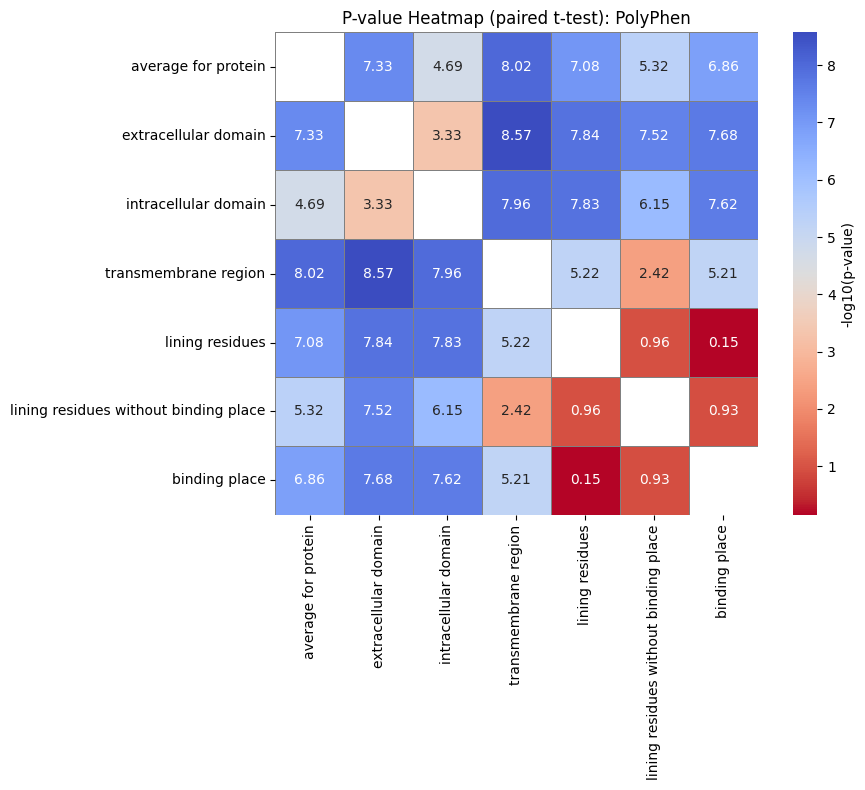

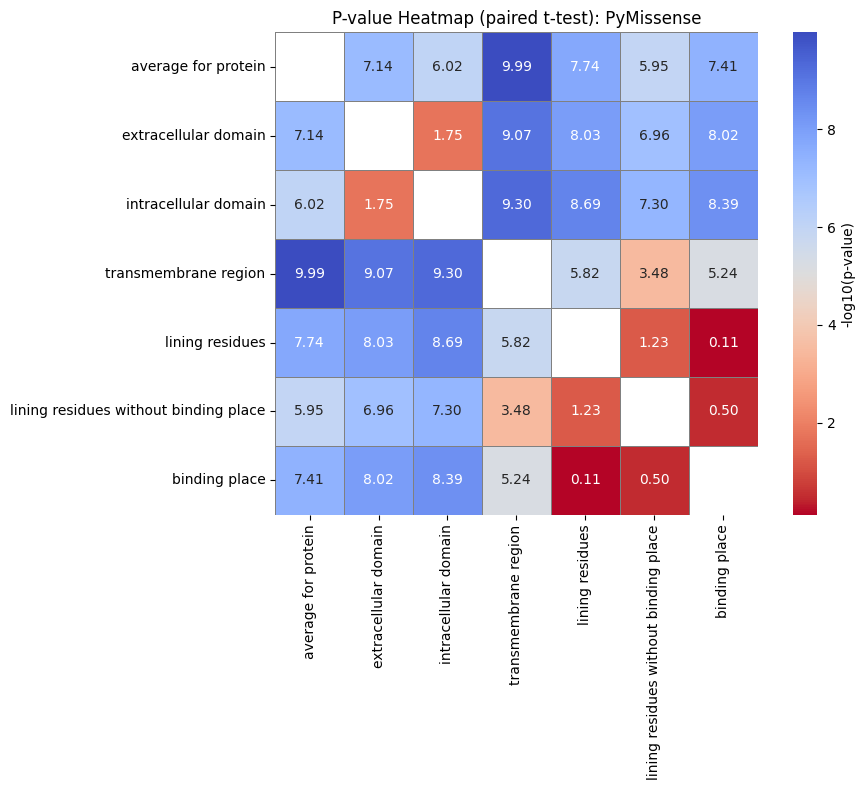

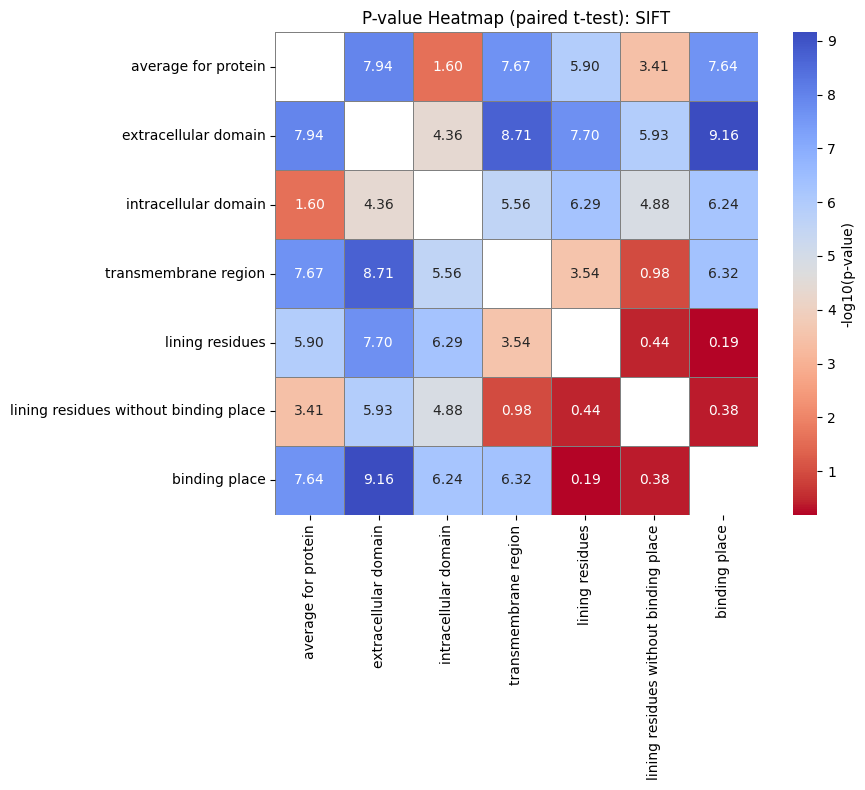

In [256]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import ttest_rel
from itertools import combinations

# --- Vybrané sloupce ---
columns_to_compare = [
    "average for protein",
    "extracellular domain", 
    "intracellular domain",
    "transmembrane region", 
    "lining residues",
    "lining residues without binding place",
    "binding place", 
]


def compute_pvalue_matrix(df, dataset_name):
    
    pval_matrix = pd.DataFrame(np.nan, index=columns_to_compare, columns=columns_to_compare)

    for col1, col2 in combinations(columns_to_compare, 2):
        values1 = df[col1]
        values2 = df[col2]
        stat, p = ttest_rel(values1, values2)
        pval_matrix.loc[col1, col2] = p
        pval_matrix.loc[col2, col1] = p  

    # Vyplň diagonálu nulami (nebo NaN)
    np.fill_diagonal(pval_matrix.values, np.nan)

    # --- Heatmap ---
    plt.figure(figsize=(10, 8))
    sns.heatmap(
        -np.log10(pval_matrix),  
        annot=True,
        fmt=".2f",
        cmap="coolwarm_r",
        cbar_kws={"label": "-log10(p-value)"},
        square=True,
        linewidths=0.5,
        linecolor='gray',
    )
    plt.title(f"P-value Heatmap (paired t-test): {dataset_name}")
    plt.tight_layout()
    plt.show()

    return pval_matrix


pval_polyphen = compute_pvalue_matrix(df1, "PolyPhen")
pval_pymissense = compute_pvalue_matrix(df2, "PyMissense")
pval_sift = compute_pvalue_matrix(df3, "SIFT")


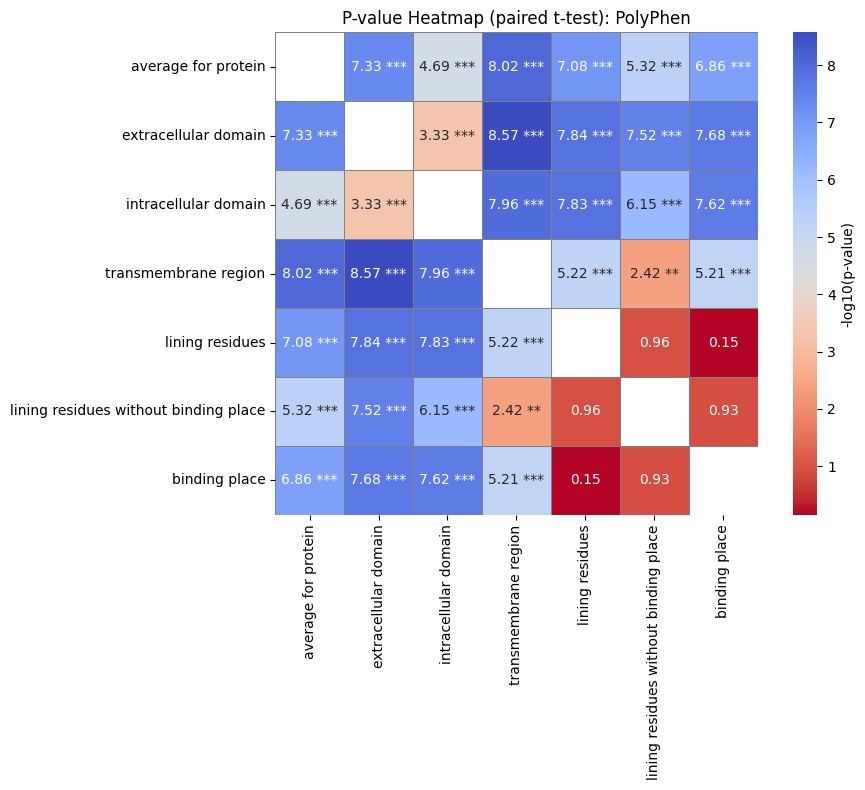

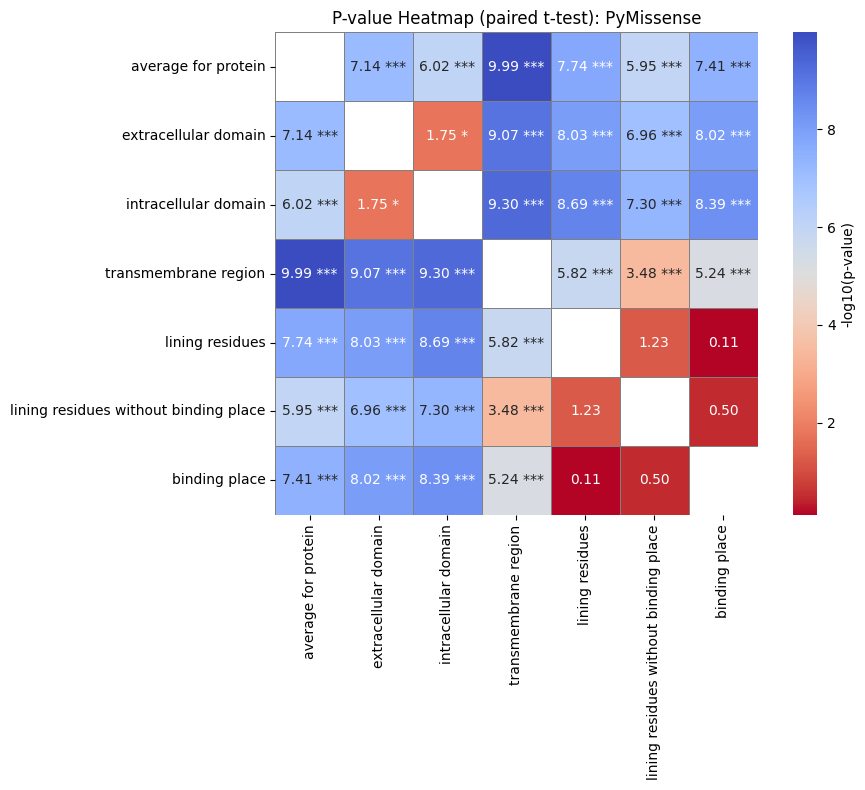

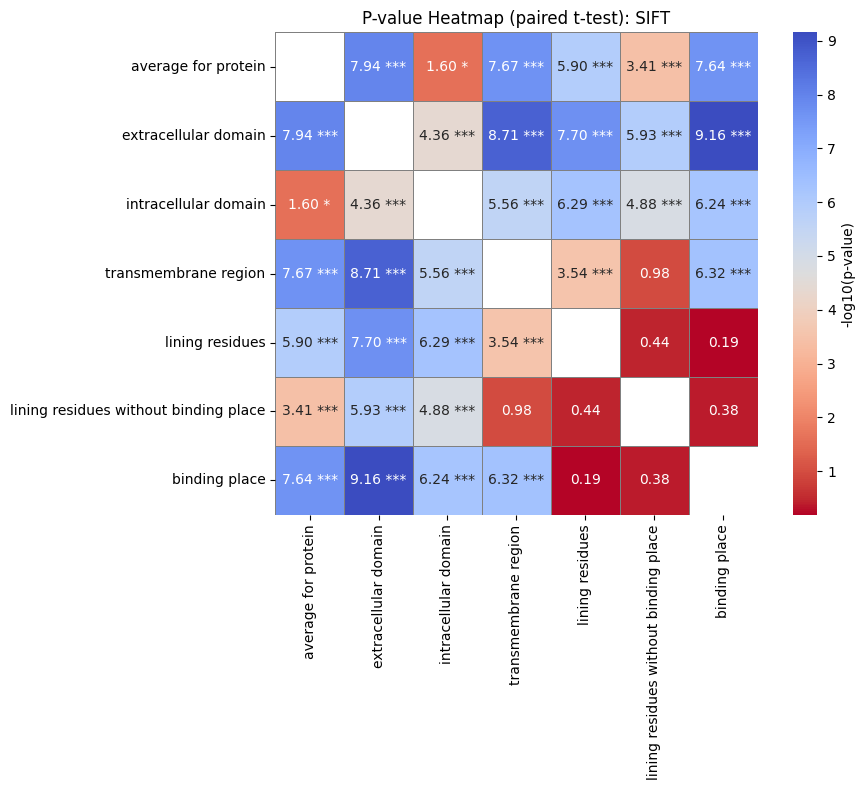

In [257]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import ttest_rel
from itertools import combinations

columns_to_compare = [
    "average for protein",
    "extracellular domain", 
    "intracellular domain",
    "transmembrane region", 
    "lining residues",
    "lining residues without binding place",
    "binding place", 
]

def compute_pvalue_matrix(df, dataset_name):
    pval_matrix = pd.DataFrame(np.nan, index=columns_to_compare, columns=columns_to_compare)

    for col1, col2 in combinations(columns_to_compare, 2):
        values1 = df[col1]
        values2 = df[col2]
        stat, p = ttest_rel(values1, values2)
        pval_matrix.loc[col1, col2] = p
        pval_matrix.loc[col2, col1] = p 

    np.fill_diagonal(pval_matrix.values, np.nan)

    # Log-transform
    log_pval = -np.log10(pval_matrix)

    # * value
    annotations = pval_matrix.copy()
    for i in annotations.index:
        for j in annotations.columns:
            p = annotations.loc[i, j]
            if pd.notna(p):
                text = f"{-np.log10(p):.2f}"
                if p < 0.001:
                    annotations.loc[i, j] = text + " ***"
                elif p < 0.01:
                    annotations.loc[i, j] = text + " **"
                elif p < 0.05:
                    annotations.loc[i, j] = text + " *"
                else:
                    annotations.loc[i, j] = text
            else:
                annotations.loc[i, j] = ""

    # --- Heatmap ---
    plt.figure(figsize=(10, 8))
    sns.heatmap(
        log_pval,
        annot=annotations,
        fmt="",
        cmap="coolwarm_r",
        cbar_kws={"label": "-log10(p-value)"},
        square=True,
        linewidths=0.5,
        linecolor='gray',
        mask=np.isnan(log_pval)
    )
    plt.title(f"P-value Heatmap (paired t-test): {dataset_name}")
    plt.tight_layout()
    plt.show()

    return pval_matrix

# compute and show
pval_polyphen = compute_pvalue_matrix(df1, "PolyPhen")
pval_pymissense = compute_pvalue_matrix(df2, "PyMissense")
pval_sift = compute_pvalue_matrix(df3, "SIFT")


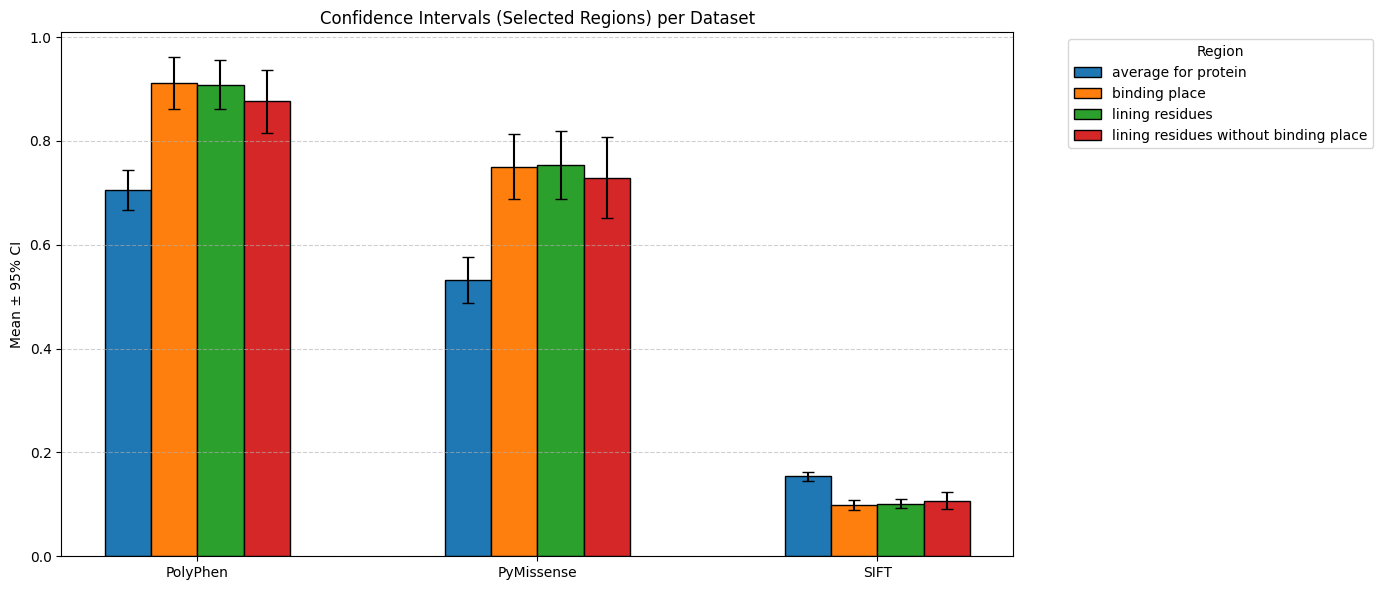

In [258]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt

# load data
def load_and_tag(filepath, dataset_name):
    df = pd.read_csv(filepath, sep="\t")
    df["Dataset"] = dataset_name
    return df

# 3 files
df1 = load_and_tag("C:/Users/annas/Downloads/Štatistika k GLUT, Nina/spojeny_subor_PolyPhen-2.txt", "PolyPhen")
df2 = load_and_tag("C:/Users/annas/Downloads/Štatistika k GLUT, Nina/spojeny_subor_PyMissense.txt", "PyMissense")
df3 = load_and_tag("C:/Users/annas/Downloads/Štatistika k GLUT, Nina/spojeny_subor_SIFT.txt", "SIFT")


selected_columns = [
    "protein",
    "average for protein",
    "binding place",
    "lining residues",
    "lining residues without binding place",
    "Dataset"  
]



df1 = df1[selected_columns]
df2 = df2[selected_columns]
df3 = df3[selected_columns]

# concat
combined = pd.concat([df1, df2, df3], ignore_index=True)
long_df = pd.melt(combined,
                  id_vars=["protein", "Dataset"],
                  var_name="Region",
                  value_name="Value")

# count CI
def compute_group_stats(df):
    results = []
    for (dataset, region), group in df.groupby(["Dataset", "Region"]):
        mean = group["Value"].mean()
        sem = stats.sem(group["Value"])
        ci = sem * stats.t.ppf((1 + 0.95) / 2., len(group["Value"]) - 1)
        results.append({
            "Dataset": dataset,
            "Region": region,
            "Mean": mean,
            "CI": ci
        })
    return pd.DataFrame(results)

summary_df = compute_group_stats(long_df)

# plot graph
datasets = summary_df["Dataset"].unique()
regions = summary_df["Region"].unique()

bar_width = 0.15
gap_between_groups = 0.5  # white space
group_positions = []

# X 
start = 0
for _ in datasets:
    positions = [start + i * bar_width for i in range(len(regions))]
    group_positions.append(positions)
    start = positions[-1] + bar_width + gap_between_groups

# picture
fig, ax = plt.subplots(figsize=(14, 6))
colors = plt.get_cmap("tab10").colors

for d_idx, dataset in enumerate(datasets):
    for r_idx, region in enumerate(regions):
        row = summary_df[(summary_df["Dataset"] == dataset) & (summary_df["Region"] == region)]
        mean = row["Mean"].values[0]
        ci = row["CI"].values[0]
        x_pos = group_positions[d_idx][r_idx]
        ax.bar(x_pos, mean, width=bar_width, yerr=ci, capsize=4,
               label=region if d_idx == 0 else "",
               color=colors[r_idx % len(colors)], edgecolor="black")

# X
xtick_positions = [np.mean(gp) for gp in group_positions]
ax.set_xticks(xtick_positions)
ax.set_xticklabels(datasets)
ax.set_ylabel("Mean ± 95% CI")
ax.set_title("Confidence Intervals (Selected Regions) per Dataset")
ax.legend(title="Region", bbox_to_anchor=(1.05, 1), loc="upper left")
ax.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()
